# Tuberculosis Trends and Geographic Patterns in the United States, 1993–2024

## Research Question

How have reported tuberculosis cases and incidence rates changed across the United States from 1993 to 2024?

## Data Source

Centers for Disease Control and Prevention (CDC)
Online Tuberculosis Information System (OTIS)

## Objectives

1. Examine national TB trends over time.
2. Compare TB incidence rates across states.
3. Identify states with substantial changes in incidence.
4. Explore unusual patterns that may warrant further public-health investigation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv(
    "/content/Tuberculosis Cases and Incidence Rates by Year and State, 1993–2024.csv"
)

In [20]:
df.head()

,Notes,Year,Year Code,State,State Code,Cases,Percent of Total,Rate per 100,000,Population
0,NaN,2020.0,2020.0,Alabama,1.0,72.0,0.02%,1.46,4921532.0,NaN
1,NaN,2020.0,2020.0,Alaska,2.0,58.0,0.01%,7.93,731158.0,NaN
2,NaN,2020.0,2020.0,Arizona,4.0,136.0,0.03%,1.83,7421401.0,NaN
3,NaN,2020.0,2020.0,Arkansas,5.0,59.0,0.01%,1.95,3030522.0,NaN
4,NaN,2020.0,2020.0,California,6.0,1703.0,0.40%,4.33,39368078.0,NaN


In [21]:
df.columns.tolist()

['Notes',
 'Year',
 'Year Code',
 'State',
 'State Code',
 'Cases',
 'Percent of Total',
 'Rate per 100',
 '000',
 'Population']

In [22]:
df = df.drop(columns=['Notes'])

In [23]:
df = df.dropna(axis=1, how='all')

In [24]:
df.head()

,Year,Year Code,State,State Code,Cases,Percent of Total,Rate per 100,000
0,2020.0,2020.0,Alabama,1.0,72.0,0.02%,1.46,4921532.0
1,2020.0,2020.0,Alaska,2.0,58.0,0.01%,7.93,731158.0
2,2020.0,2020.0,Arizona,4.0,136.0,0.03%,1.83,7421401.0
3,2020.0,2020.0,Arkansas,5.0,59.0,0.01%,1.95,3030522.0
4,2020.0,2020.0,California,6.0,1703.0,0.40%,4.33,39368078.0


In [25]:
df.describe()


,Year,Year Code,State Code,Cases,Rate per 100,000
count,1664.000000,1664.000000,1632.000000,1665.000000,1665.000000,1.665000e+03
mean,2008.500000,2008.500000,28.960784,775.650450,3.658697,1.746502e+07
std,9.235868,9.235868,15.681641,10725.713767,3.130464,2.408568e+08
min,1993.000000,1993.000000,1.000000,0.000000,0.000000,4.730810e+05
25%,2000.750000,2000.750000,16.000000,40.000000,1.580000,1.682398e+06
50%,2008.500000,2008.500000,29.000000,111.000000,2.670000,4.241507e+06
75%,2016.250000,2016.250000,42.000000,261.000000,4.700000,7.291843e+06
max,2024.000000,2024.000000,56.000000,430486.000000,27.210000,9.693087e+09


In [26]:
df = df.drop(columns=['Year Code'])

In [27]:
df = df.rename(columns={'000':'Population'})

In [28]:
df.head()

,Year,State,State Code,Cases,Percent of Total,Rate per 100,Population
0,2020.0,Alabama,1.0,72.0,0.02%,1.46,4921532.0
1,2020.0,Alaska,2.0,58.0,0.01%,7.93,731158.0
2,2020.0,Arizona,4.0,136.0,0.03%,1.83,7421401.0
3,2020.0,Arkansas,5.0,59.0,0.01%,1.95,3030522.0
4,2020.0,California,6.0,1703.0,0.40%,4.33,39368078.0


In [29]:
df = df.rename(columns={'Rate per 100':'Rate per 100,000'})

In [30]:
df.head()

,Year,State,State Code,Cases,Percent of Total,"Rate per 100,000",Population
0,2020.0,Alabama,1.0,72.0,0.02%,1.46,4921532.0
1,2020.0,Alaska,2.0,58.0,0.01%,7.93,731158.0
2,2020.0,Arizona,4.0,136.0,0.03%,1.83,7421401.0
3,2020.0,Arkansas,5.0,59.0,0.01%,1.95,3030522.0
4,2020.0,California,6.0,1703.0,0.40%,4.33,39368078.0


In [31]:
df.shape

(1710, 7)

In [32]:
df.isna().sum()

,0
Year,46
State,78
State Code,78
Cases,45
Percent of Total,45
"Rate per 100,000",45
Population,45


In [33]:
df[df['State'].isna()]

,Year,State,State Code,Cases,Percent of Total,"Rate per 100,000",Population
51,2020.0,NaN,NaN,7170.0,1.67%,2.18,329484123.0
103,2021.0,NaN,NaN,7866.0,1.83%,2.37,332048977.0
155,2022.0,NaN,NaN,8335.0,1.94%,2.50,333271411.0
207,2023.0,NaN,NaN,9626.0,2.24%,2.87,334914895.0
259,2024.0,NaN,NaN,10388.0,2.41%,3.05,340110988.0
...,...,...,...,...,...,...,...
1705,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1707,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1708,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
national_totals = df[
    df['State'].isna() & df['Cases'].notna()
].copy()

In [35]:
national_totals


,Year,State,State Code,Cases,Percent of Total,"Rate per 100,000",Population
51,2020.0,NaN,NaN,7170.0,1.67%,2.18,3.294841e+08
103,2021.0,NaN,NaN,7866.0,1.83%,2.37,3.320490e+08
155,2022.0,NaN,NaN,8335.0,1.94%,2.50,3.332714e+08
207,2023.0,NaN,NaN,9626.0,2.24%,2.87,3.349149e+08
259,2024.0,NaN,NaN,10388.0,2.41%,3.05,3.401110e+08
311,2019.0,NaN,NaN,8895.0,2.07%,2.71,3.283300e+08
363,2018.0,NaN,NaN,8997.0,2.09%,2.75,3.268382e+08
415,2017.0,NaN,NaN,9068.0,2.11%,2.79,3.251221e+08
467,2016.0,NaN,NaN,9239.0,2.15%,2.86,3.230718e+08
519,2015.0,NaN,NaN,9539.0,2.22%,2.97,3.207390e+08


In [36]:
national_totals.shape

(33, 7)

In [37]:
df = df[df['State'].notna()].copy()

In [38]:
df.shape

(1632, 7)

In [39]:
df.isna().sum()

,0
Year,0
State,0
State Code,0
Cases,0
Percent of Total,0
"Rate per 100,000",0
Population,0


In [40]:
df['State'].unique()

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'], dtype=object)

In [41]:
sorted(df['Year'].unique())

[np.float64(1993.0),
 np.float64(1994.0),
 np.float64(1995.0),
 np.float64(1996.0),
 np.float64(1997.0),
 np.float64(1998.0),
 np.float64(1999.0),
 np.float64(2000.0),
 np.float64(2001.0),
 np.float64(2002.0),
 np.float64(2003.0),
 np.float64(2004.0),
 np.float64(2005.0),
 np.float64(2006.0),
 np.float64(2007.0),
 np.float64(2008.0),
 np.float64(2009.0),
 np.float64(2010.0),
 np.float64(2011.0),
 np.float64(2012.0),
 np.float64(2013.0),
 np.float64(2014.0),
 np.float64(2015.0),
 np.float64(2016.0),
 np.float64(2017.0),
 np.float64(2018.0),
 np.float64(2019.0),
 np.float64(2020.0),
 np.float64(2021.0),
 np.float64(2022.0),
 np.float64(2023.0),
 np.float64(2024.0)]

In [43]:
df['State'].nunique()

51

In [44]:
df.dtypes

,0
Year,float64
State,object
State Code,float64
Cases,float64
Percent of Total,object
"Rate per 100,000",float64
Population,float64


In [45]:
df['Year'] = df['Year'].astype(int)
df['Cases'] = df['Cases'].astype(int)
df['Population'] = df['Population'].astype(int)
df['Rate per 100,000'] = df['Rate per 100,000'].astype(float)

In [46]:
df.dtypes

,0
Year,int64
State,object
State Code,float64
Cases,int64
Percent of Total,object
"Rate per 100,000",float64
Population,int64


In [47]:
df['Percent of Total'] = (
    df['Percent of Total']
    .str.replace('%', '', regex=False)
    .astype(float)
)

In [48]:
df.dtypes

,0
Year,int64
State,object
State Code,float64
Cases,int64
Percent of Total,float64
"Rate per 100,000",float64
Population,int64


In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df.isna().sum()

,0
Year,0
State,0
State Code,0
Cases,0
Percent of Total,0
"Rate per 100,000",0
Population,0


## 1. Data Cleaning

The CDC dataset was inspected for unnecessary columns, missing values,
and inconsistent column names.

The `Notes` column was removed because it contained no useful analytical data.
Completely empty columns were also removed.

Column names were renamed to make them easier to work with in Python.

In [51]:
#Analysis 1: - Total No. of cases from 1993-2024

national_trend = (
    df.groupby('Year')['Cases']
    .sum()
    .reset_index()
)

In [52]:
national_trend

,Year,Cases
0,1993,25102
1,1994,24206
2,1995,22726
3,1996,21212
4,1997,19751
5,1998,18285
6,1999,17492
7,2000,16305
8,2001,15937
9,2002,15048


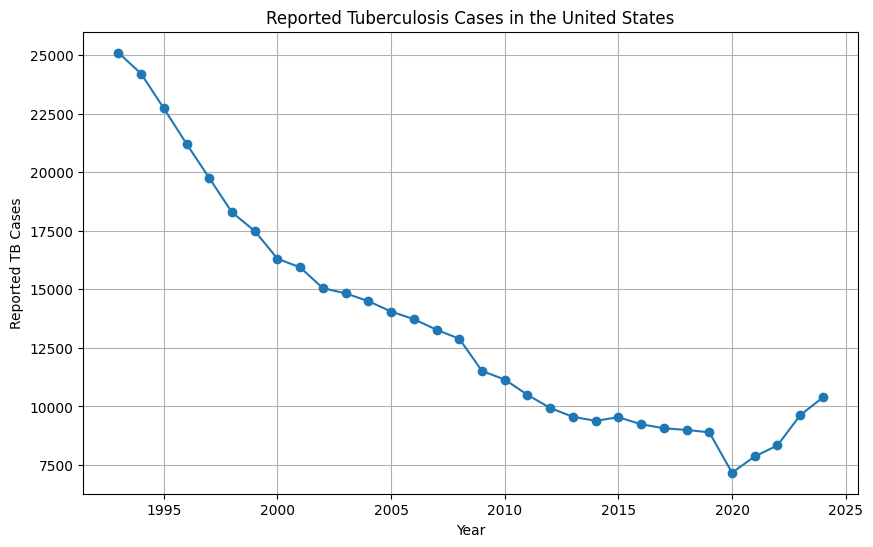

In [53]:
#Data Visualization
plt.figure(figsize=(10, 6))

plt.plot(
    national_trend['Year'],
    national_trend['Cases'],
    marker='o'
)

plt.title('Reported Tuberculosis Cases in the United States')
plt.xlabel('Year')
plt.ylabel('Reported TB Cases')

plt.grid(True)
plt.show()

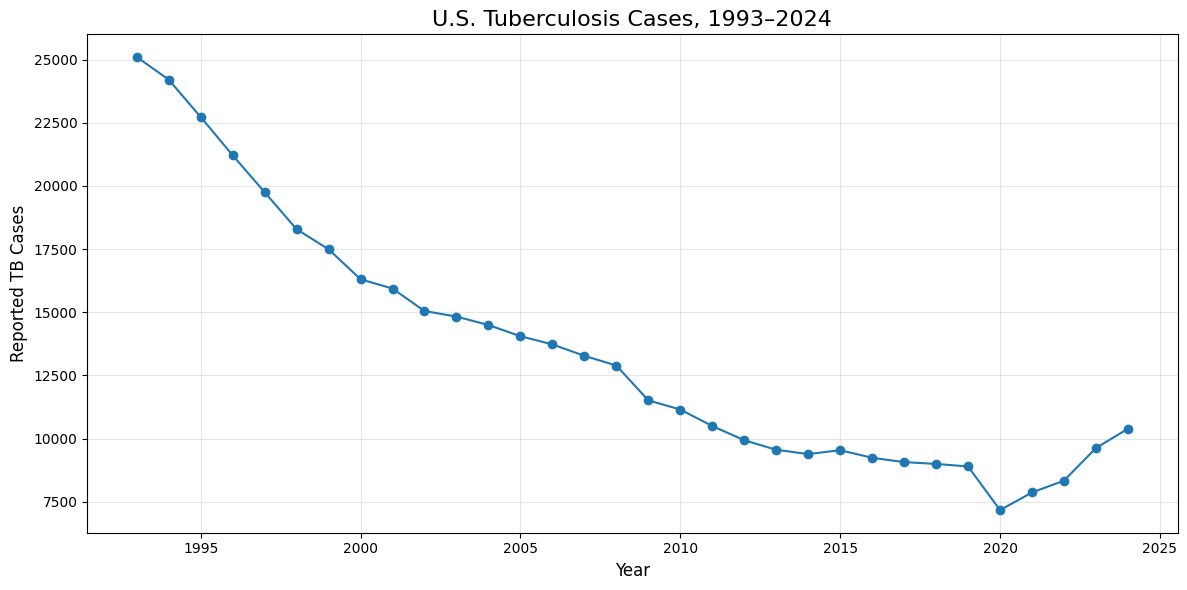

In [54]:
plt.figure(figsize=(12, 6))

plt.plot(
    national_trend['Year'],
    national_trend['Cases'],
    marker='o'
)

plt.title('U.S. Tuberculosis Cases, 1993–2024', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Reported TB Cases', fontsize=12)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
# Analysis 2: Top states by TB incidence rate in 2024

latest_year = df['Year'].max()

state_rates_2024 = (
    df[df['Year'] == latest_year]
    [['State', 'Cases', 'Rate per 100,000', 'Population']]
    .sort_values('Rate per 100,000', ascending=False)
)

top_10_states = state_rates_2024.head(10)

top_10_states

,State,Cases,"Rate per 100,000",Population
209,Alaska,91,12.30,740133
219,Hawaii,117,8.09,1446146
240,New York,1083,5.45,19867248
212,California,2109,5.35,39431263
216,District of Columbia,33,4.70,702250
251,Texas,1279,4.09,31290831
211,Arkansas,119,3.85,3088354
224,Kansas,114,3.84,2970606
238,New Jersey,342,3.60,9500851
229,Massachusetts,254,3.56,7136171


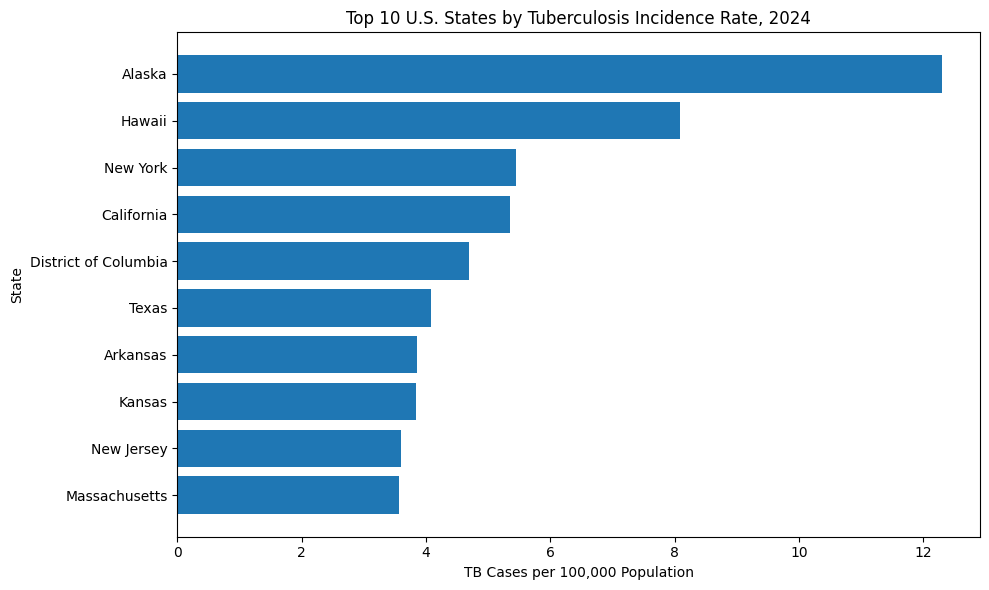

In [56]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_states['State'][::-1],
    top_10_states['Rate per 100,000'][::-1]
)

plt.title('Top 10 U.S. States by Tuberculosis Incidence Rate, 2024')
plt.xlabel('TB Cases per 100,000 Population')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [57]:
#Analysis 3: How did TB rates change by state over time?

top_5_states = top_10_states.head(5)['State'].tolist()

top_5_states

['Alaska', 'Hawaii', 'New York', 'California', 'District of Columbia']

In [58]:
state_trends = df[
    df['State'].isin(top_5_states)
].copy()

state_trends.head()

,Year,State,State Code,Cases,Percent of Total,"Rate per 100,000",Population
1,2020,Alaska,2.0,58,0.01,7.93,731158
4,2020,California,6.0,1703,0.40,4.33,39368078
8,2020,District of Columbia,11.0,19,0.00,2.67,712816
11,2020,Hawaii,15.0,92,0.02,6.54,1407006
32,2020,New York,36.0,605,0.14,3.13,19336776


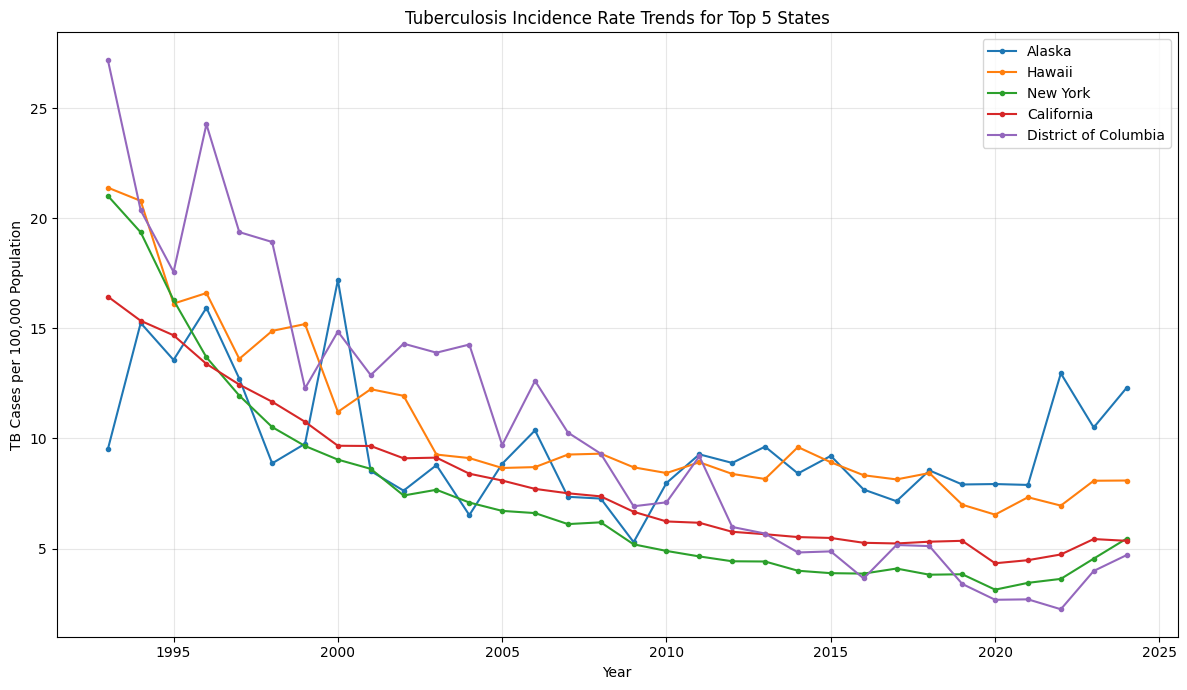

In [59]:
plt.figure(figsize=(12, 7))

for state in top_5_states:
    state_data = state_trends[
        state_trends['State'] == state
    ].sort_values('Year')

    plt.plot(
        state_data['Year'],
        state_data['Rate per 100,000'],
        marker='o',
        markersize=3,
        label=state
    )

plt.title('Tuberculosis Incidence Rate Trends for Top 5 States')
plt.xlabel('Year')
plt.ylabel('TB Cases per 100,000 Population')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [60]:
#Analysis 4: Which states experienced the largest increases after 2020?

rates_2020 = (
    df[df['Year'] == 2020]
    [['State', 'Rate per 100,000']]
    .rename(columns={
        'Rate per 100,000': 'Rate_2020'
    })
)

rates_2024 = (
    df[df['Year'] == 2024]
    [['State', 'Rate per 100,000']]
    .rename(columns={
        'Rate per 100,000': 'Rate_2024'
    })
)

rate_change = rates_2020.merge(
    rates_2024,
    on='State',
    how='inner'
)

rate_change.head()

,State,Rate_2020,Rate_2024
0,Alabama,1.46,1.74
1,Alaska,7.93,12.30
2,Arizona,1.83,2.77
3,Arkansas,1.95,3.85
4,California,4.33,5.35


In [61]:
rates_2020 = (
    df[df['Year'] == 2020]
    [['State', 'Rate per 100,000']]
    .rename(columns={
        'Rate per 100,000': 'Rate_2020'
    })
)

rates_2024 = (
    df[df['Year'] == 2024]
    [['State', 'Rate per 100,000']]
    .rename(columns={
        'Rate per 100,000': 'Rate_2024'
    })
)

rate_change = rates_2020.merge(
    rates_2024,
    on='State',
    how='inner'
)

rate_change.head()

,State,Rate_2020,Rate_2024
0,Alabama,1.46,1.74
1,Alaska,7.93,12.30
2,Arizona,1.83,2.77
3,Arkansas,1.95,3.85
4,California,4.33,5.35


In [62]:
rate_change['Absolute_Change'] = (
    rate_change['Rate_2024'] -
    rate_change['Rate_2020']
)

rate_change['Percent_Change'] = (
    (rate_change['Rate_2024'] -
     rate_change['Rate_2020'])
    / rate_change['Rate_2020']
) * 100

In [63]:
largest_increases = (
    rate_change
    .sort_values('Absolute_Change', ascending=False)
    .head(10)
)

largest_increases

,State,Rate_2020,Rate_2024,Absolute_Change,Percent_Change
1,Alaska,7.93,12.30,4.37,55.107188
16,Kansas,1.27,3.84,2.57,202.362205
32,New York,3.13,5.45,2.32,74.121406
8,District of Columbia,2.67,4.70,2.03,76.029963
3,Arkansas,1.95,3.85,1.90,97.435897
11,Hawaii,6.54,8.09,1.55,23.700306
19,Maine,1.26,2.78,1.52,120.634921
21,Massachusetts,2.06,3.56,1.50,72.815534
39,Rhode Island,0.66,2.07,1.41,213.636364
23,Minnesota,2.07,3.35,1.28,61.835749


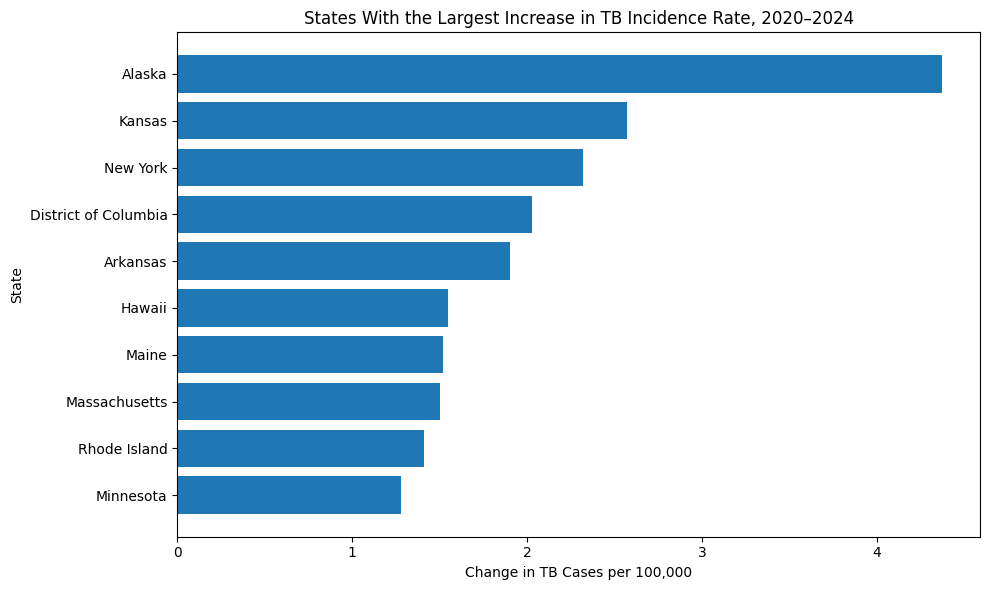

In [64]:
plt.figure(figsize=(10, 6))

plt.barh(
    largest_increases['State'][::-1],
    largest_increases['Absolute_Change'][::-1]
)

plt.title('States With the Largest Increase in TB Incidence Rate, 2020–2024')
plt.xlabel('Change in TB Cases per 100,000')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [65]:
#Analysis 5: Does population size explain the number of TB cases?
population_cases = df[
    df['Year'] == 2024
][
    ['State', 'Population', 'Cases', 'Rate per 100,000']
].copy()

population_cases.head()

,State,Population,Cases,"Rate per 100,000"
208,Alabama,5157699,90,1.74
209,Alaska,740133,91,12.30
210,Arizona,7582384,210,2.77
211,Arkansas,3088354,119,3.85
212,California,39431263,2109,5.35


In [66]:
correlation = population_cases[
    ['Population', 'Cases']
].corr().iloc[0, 1]

print(f"Correlation between population and TB cases: {correlation:.3f}")

Correlation between population and TB cases: 0.942


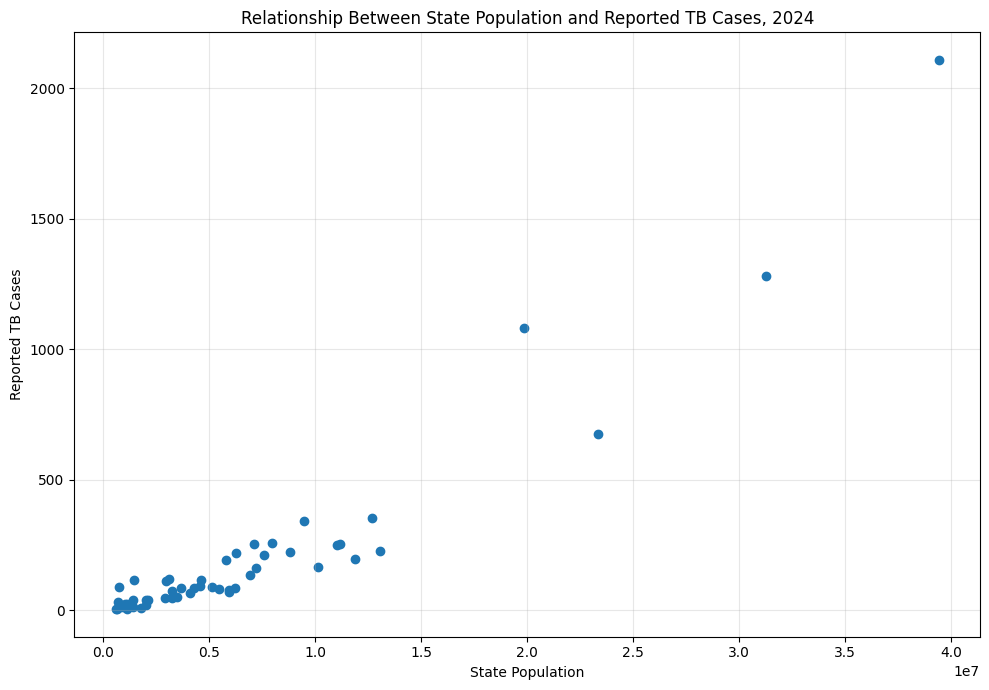

In [67]:
plt.figure(figsize=(10, 7))

plt.scatter(
    population_cases['Population'],
    population_cases['Cases']
)

plt.title('Relationship Between State Population and Reported TB Cases, 2024')
plt.xlabel('State Population')
plt.ylabel('Reported TB Cases')

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

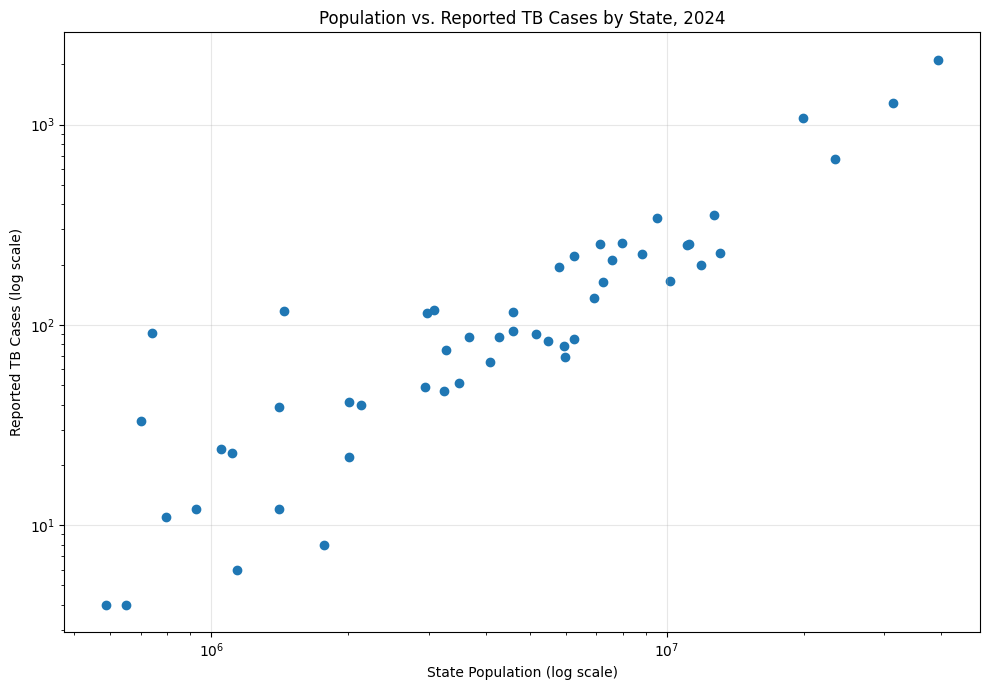

In [68]:
plt.figure(figsize=(10, 7))

plt.scatter(
    population_cases['Population'],
    population_cases['Cases']
)

plt.xscale('log')
plt.yscale('log')

plt.title('Population vs. Reported TB Cases by State, 2024')
plt.xlabel('State Population (log scale)')
plt.ylabel('Reported TB Cases (log scale)')

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [69]:
#Analysis 6: Which states consistently had high TB incidence?
#Calculate average TB rate
state_average_rate = (
    df.groupby('State')['Rate per 100,000']
    .agg(
        Average_Rate='mean',
        Median_Rate='median',
        Maximum_Rate='max',
        Minimum_Rate='min'
    )
    .reset_index()
    .sort_values('Average_Rate', ascending=False)
)

state_average_rate.head(10)

,State,Average_Rate,Median_Rate,Maximum_Rate,Minimum_Rate
11,Hawaii,10.573750,8.920,21.40,6.54
8,District of Columbia,10.321250,9.250,27.21,2.24
1,Alaska,9.677500,8.860,17.20,5.29
4,California,8.073125,7.020,16.45,4.33
32,New York,7.348438,5.780,21.03,3.13
43,Texas,6.526250,6.095,13.53,2.99
30,New Jersey,5.457813,4.725,11.46,2.76
9,Florida,5.436562,4.790,12.23,1.90
10,Georgia,5.334375,4.640,11.59,2.05
18,Louisiana,4.991875,4.580,10.82,1.86


In [70]:
#Rank states every year
df_ranked = df.copy()

df_ranked['Yearly_Rank'] = (
    df_ranked
    .groupby('Year')['Rate per 100,000']
    .rank(
        ascending=False,
        method='min'
    )
)

df_ranked.head()

,Year,State,State Code,Cases,Percent of Total,"Rate per 100,000",Population,Yearly_Rank
0,2020,Alabama,1.0,72,0.02,1.46,4921532,29.0
1,2020,Alaska,2.0,58,0.01,7.93,731158,1.0
2,2020,Arizona,4.0,136,0.03,1.83,7421401,17.0
3,2020,Arkansas,5.0,59,0.01,1.95,3030522,15.0
4,2020,California,6.0,1703,0.40,4.33,39368078,3.0


In [71]:
#Count how often each state was in the top 10
top_10_frequency = (
    df_ranked[df_ranked['Yearly_Rank'] <= 10]
    .groupby('State')
    .size()
    .reset_index(name='Years_in_Top_10')
    .sort_values('Years_in_Top_10', ascending=False)
)

top_10_frequency.head(15)

,State,Years_in_Top_10
4,California,32
22,Texas,32
19,New York,32
9,Hawaii,32
6,District of Columbia,31
1,Alaska,31
18,New Jersey,24
7,Florida,23
8,Georgia,20
13,Maryland,13


In [72]:
consistency_analysis = state_average_rate.merge(
    top_10_frequency,
    on='State',
    how='left'
)

consistency_analysis['Years_in_Top_10'] = (
    consistency_analysis['Years_in_Top_10']
    .fillna(0)
    .astype(int)
)

consistency_analysis = consistency_analysis.sort_values(
    ['Years_in_Top_10', 'Average_Rate'],
    ascending=[False, False]
)

consistency_analysis.head(15)

,State,Average_Rate,Median_Rate,Maximum_Rate,Minimum_Rate,Years_in_Top_10
0,Hawaii,10.573750,8.920,21.40,6.54,32
3,California,8.073125,7.020,16.45,4.33,32
4,New York,7.348438,5.780,21.03,3.13,32
5,Texas,6.526250,6.095,13.53,2.99,32
1,District of Columbia,10.321250,9.250,27.21,2.24,31
2,Alaska,9.677500,8.860,17.20,5.29,31
6,New Jersey,5.457813,4.725,11.46,2.76,24
7,Florida,5.436562,4.790,12.23,1.90,23
8,Georgia,5.334375,4.640,11.59,2.05,20
9,Louisiana,4.991875,4.580,10.82,1.86,13


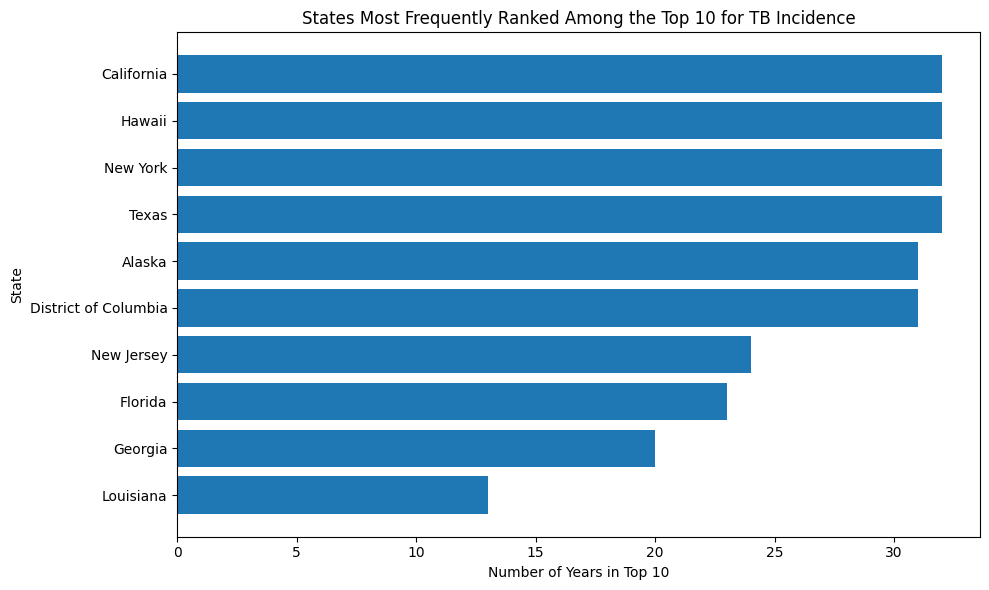

In [73]:
top_consistent_states = (
    consistency_analysis
    .head(10)
    .sort_values('Years_in_Top_10')
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_consistent_states['State'],
    top_consistent_states['Years_in_Top_10']
)

plt.title('States Most Frequently Ranked Among the Top 10 for TB Incidence')
plt.xlabel('Number of Years in Top 10')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [74]:
#Analysis 6: COVID-era TB reporting change
covid_change = national_trend.copy()

covid_change['Percent_Change'] = (
    covid_change['Cases']
    .pct_change() * 100
)

covid_change

,Year,Cases,Percent_Change
0,1993,25102,NaN
1,1994,24206,-3.569437
2,1995,22726,-6.114187
3,1996,21212,-6.661973
4,1997,19751,-6.887611
5,1998,18285,-7.422409
6,1999,17492,-4.336888
7,2000,16305,-6.785959
8,2001,15937,-2.256976
9,2002,15048,-5.578214


In [79]:
#Calculating Specifically 2020 → 2021
cases_2020 = national_trend.loc[
    national_trend['Year'] == 2020,
    'Cases'
].iloc[0]

cases_2021 = national_trend.loc[
    national_trend['Year'] == 2021,
    'Cases'
].iloc[0]

change_2020_2021 = (
    (cases_2021 - cases_2020)
    / cases_2020
) * 100

print(
    f"Change in reported TB cases from 2020 to 2021: "
    f"{change_2020_2021:.2f}%"
)

Change in reported TB cases from 2020 to 2021: 9.71%


In [78]:
#Calculating change 2020 → 2024
cases_2020 = national_trend.loc[
    national_trend['Year'] == 2020,
    'Cases'
].iloc[0]

cases_2024 = national_trend.loc[
    national_trend['Year'] == 2024,
    'Cases'
].iloc[0]

change_2020_2024 = (
    (cases_2024 - cases_2020)
    / cases_2020
) * 100

print(
    f"Change in reported TB cases from 2020 to 2024: "
    f"{change_2020_2024:.2f}%"
)

Change in reported TB cases from 2020 to 2024: 44.88%


In [81]:
cases_2020 = national_trend.loc[
    national_trend['Year'] == 2020, 'Cases'
].iloc[0]

cases_2021 = national_trend.loc[
    national_trend['Year'] == 2021, 'Cases'
].iloc[0]

cases_2024 = national_trend.loc[
    national_trend['Year'] == 2024, 'Cases'
].iloc[0]

change_2020_2021 = ((cases_2021 - cases_2020) / cases_2020) * 100

change_2021_2024 = ((cases_2024 - cases_2021) / cases_2021) * 100

change_2020_2024 = ((cases_2024 - cases_2020) / cases_2020) * 100

print(f"2020 → 2021: {change_2020_2021:.2f}%")
print(f"2021 → 2024: {change_2021_2024:.2f}%")
print(f"2020 → 2024: {change_2020_2024:.2f}%")

2020 → 2021: 9.71%
2021 → 2024: 32.06%
2020 → 2024: 44.88%


## Analysis 1: National TB Trend

### Objective

The first analysis examines how the number of reported tuberculosis (TB) cases in the United States changed over time, with particular focus on the period following 2020.

### Key Findings

- Reported TB cases increased by **9.71% from 2020 to 2021**.
- Reported TB cases increased by an additional **32.06% from 2021 to 2024**.
- Overall, reported TB cases increased by **44.88% between 2020 and 2024**.

### Interpretation

The data show a substantial rebound in reported TB cases following the decline observed in 2020. The increase continued through 2024, with reported cases rising by nearly 45% compared with 2020.

This pattern indicates a strong post-2020 recovery in TB case reporting. However, the increase in reported cases should not be interpreted as a direct increase in underlying TB transmission, since surveillance data can also be influenced by changes in healthcare access, testing, diagnosis, and reporting.

### Conclusion

The national trend demonstrates a significant post-2020 increase in reported TB cases. This finding motivates further analysis of **state-level TB incidence rates** to determine whether the rebound occurred consistently across the United States or was concentrated in specific states.


> **Key Takeaway:** Reported TB cases increased by **44.88% from 2020 to 2024**, indicating a substantial post-2020 rebound in national TB case reporting.

